--- Raw Extracted Data Sample ---
            timestamp        route_id   latitude  longitude  \
0 2026-03-26 08:00:00  Waterloo_Hub_A  43.232359 -80.301101   
1 2026-03-26 08:05:00  Waterloo_Hub_A  43.125423 -80.379649   
2 2026-03-26 08:10:00  Waterloo_Hub_A  43.224393 -80.386064   
3 2026-03-26 08:15:00  Waterloo_Hub_A  43.230073 -80.485245   
4 2026-03-26 08:20:00  Waterloo_Hub_A  43.391842 -80.256174   

   cargo_temp_celsius  
0          -19.503286  
1          -20.138264  
2          -19.352311  
3          -18.476970  
4          -20.234153  

--- Transformed Risk Summary ---
          route_id  total_pings  risk_events  risk_percentage
0  Brantford_Hub_B           60           23        38.333333
1   Waterloo_Hub_A           60            0         0.000000


/tmp/ipykernel_27276/1902047502.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=risk_summary, x='route_id', y='risk_percentage', palette=['#2ecc71', '#e74c3c'])


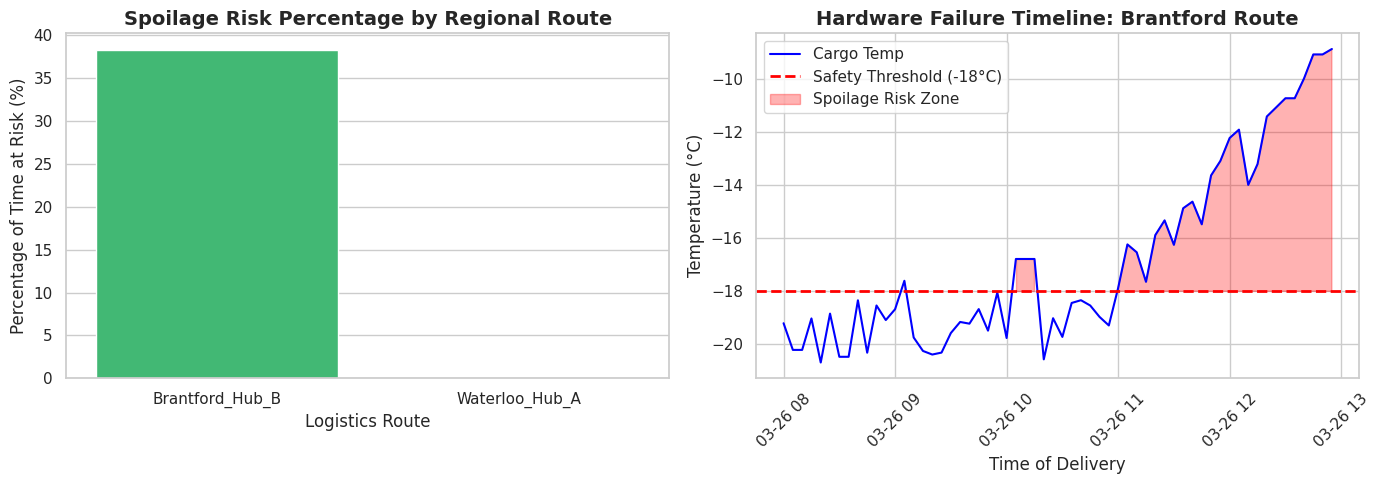

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# ==========================================
# 1. EXTRACT: Simulating Messy Telemetry Data
# ==========================================
np.random.seed(42)

def generate_truck_data(route_name, num_records, base_temp, failure_index=None):
    base_time = datetime(2026, 3, 26, 8, 0) # Starting at 8:00 AM
    timestamps = [base_time + timedelta(minutes=5 * i) for i in range(num_records)]

    # Simulate normal temperatures with slight fluctuations
    temps = np.random.normal(base_temp, 1.0, num_records)

    # Simulate a cooling unit failure (temperature spikes above -18C)
    if failure_index:
        temps[failure_index:] = temps[failure_index:] + np.linspace(0, 10, num_records - failure_index)

    df = pd.DataFrame({
        'timestamp': timestamps,
        'route_id': route_name,
        # Simulating localized geospatial coordinates
        'latitude': np.random.uniform(43.1, 43.5, num_records),
        'longitude': np.random.uniform(-80.5, -80.1, num_records),
        'cargo_temp_celsius': temps
    })
    return df

# Generate Waterloo data (Normal delivery)
df_waterloo = generate_truck_data('Waterloo_Hub_A', 60, -20.0)

# Generate Brantford data (Hardware failure halfway through)
df_brantford = generate_truck_data('Brantford_Hub_B', 60, -19.5, failure_index=30)

# Combine and inject "messy" data (missing IoT pings)
raw_data = pd.concat([df_waterloo, df_brantford]).reset_index(drop=True)
messy_indices = np.random.choice(raw_data.index, size=10, replace=False)
raw_data.loc[messy_indices, 'cargo_temp_celsius'] = np.nan

print("--- Raw Extracted Data Sample ---")
print(raw_data.head())

# ==========================================
# 2. TRANSFORM: The Engineering Core
# ==========================================

# A. Clean Data: Forward-fill missing temperatures (standard IoT practice for brief outages)
clean_data = raw_data.copy()
clean_data['cargo_temp_celsius'] = clean_data.groupby('route_id')['cargo_temp_celsius'].ffill()

# B. Feature Engineering: Flag temperatures > -18°C
SAFETY_THRESHOLD = -18.0
clean_data['temp_violation'] = clean_data['cargo_temp_celsius'] > SAFETY_THRESHOLD

# C. Complex Logic: Flag if violation lasts for 15+ consecutive minutes (3 rolling periods of 5 mins)
# We calculate a rolling sum of violations. If it hits 3, the spoilage risk is triggered.
clean_data['rolling_violation_count'] = clean_data.groupby('route_id')['temp_violation'].transform(
    lambda x: x.rolling(window=3, min_periods=1).sum()
)

clean_data['spoilage_risk_flag'] = clean_data['rolling_violation_count'] >= 3

# D. Aggregation for Stakeholders
risk_summary = clean_data.groupby('route_id').agg(
    total_pings=('timestamp', 'count'),
    risk_events=('spoilage_risk_flag', 'sum')
).reset_index()

risk_summary['risk_percentage'] = (risk_summary['risk_events'] / risk_summary['total_pings']) * 100

print("\n--- Transformed Risk Summary ---")
print(risk_summary)

# ==========================================
# 3. LOAD & VISUALIZE: The Stakeholder Data Story
# ==========================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))

# Visual 1: Route Risk Bar Chart
plt.subplot(1, 2, 1)
sns.barplot(data=risk_summary, x='route_id', y='risk_percentage', palette=['#2ecc71', '#e74c3c'])
plt.title('Spoilage Risk Percentage by Regional Route', fontsize=14, weight='bold')
plt.ylabel('Percentage of Time at Risk (%)')
plt.xlabel('Logistics Route')

# Visual 2: Temperature vs. Time Scatter Plot (Focusing on the failing route)
plt.subplot(1, 2, 2)
brantford_clean = clean_data[clean_data['route_id'] == 'Brantford_Hub_B']

sns.lineplot(data=brantford_clean, x='timestamp', y='cargo_temp_celsius', color='blue', label='Cargo Temp')
plt.axhline(SAFETY_THRESHOLD, color='red', linestyle='--', linewidth=2, label='Safety Threshold (-18°C)')

# Highlight the risk zone
plt.fill_between(brantford_clean['timestamp'],
                 brantford_clean['cargo_temp_celsius'],
                 SAFETY_THRESHOLD,
                 where=(brantford_clean['cargo_temp_celsius'] > SAFETY_THRESHOLD),
                 color='red', alpha=0.3, label='Spoilage Risk Zone')

plt.title('Hardware Failure Timeline: Brantford Route', fontsize=14, weight='bold')
plt.ylabel('Temperature (°C)')
plt.xlabel('Time of Delivery')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

This project simulates a common data engineering pipeline for IoT telemetry data, specifically tracking cargo temperatures in delivery trucks. It covers the crucial **Extract, Transform, and Load (ETL)** stages, culminating in visualizations for stakeholders. As a data engineer, you'd be responsible for building and maintaining such pipelines.

## 1. EXTRACT: Simulating Messy Telemetry Data

This section focuses on simulating raw, real-world data, including anomalies and missing values, which is typical for a data engineer to encounter when extracting data from various sources (e.g., IoT sensors, APIs, databases).

In [8]:
import pandas as pd # Essential for data manipulation and analysis using DataFrames.
import numpy as np  # Used for numerical operations, especially for generating random data.
import matplotlib.pyplot as plt # Core library for creating static, interactive, and animated visualizations.
import seaborn as sns # Built on Matplotlib, provides a high-level interface for drawing attractive statistical graphics.
from datetime import datetime, timedelta # Used for working with dates and times, crucial for time-series data.

# Ensures that the random numbers generated are the same every time the code runs, which is vital for reproducibility in testing and development.
np.random.seed(42)

### `generate_truck_data` Function

This function simulates a single truck's telemetry data over a period. Data engineers often work with functions or modules that generate or ingest data, often from APIs, databases, or streaming sources.

In [9]:
def generate_truck_data(route_name, num_records, base_temp, failure_index=None):
    # Defines a consistent start time for the simulated data, ensuring that timestamps are sequential.
    base_time = datetime(2026, 3, 26, 8, 0) # Starting at 8:00 AM
    # Generates a sequence of timestamps, simulating data points recorded every 5 minutes.
    timestamps = [base_time + timedelta(minutes=5 * i) for i in range(num_records)]

    # Simulates normal temperature readings with slight random fluctuations around a base temperature.
    temps = np.random.normal(base_temp, 1.0, num_records)

    # Introduces a simulated hardware failure: temperatures begin to rise after a specific point (failure_index).
    # This mimics real-world scenarios where equipment might malfunction.
    if failure_index:
        temps[failure_index:] = temps[failure_index:] + np.linspace(0, 10, num_records - failure_index)

    # Creates a Pandas DataFrame, which is the primary data structure for data engineers to work with tabular data.
    df = pd.DataFrame({
        'timestamp': timestamps,
        'route_id': route_name,
        # Simulates localized geospatial coordinates, often critical for logistics and IoT data.
        'latitude': np.random.uniform(43.1, 43.5, num_records),
        'longitude': np.random.uniform(-80.5, -80.1, num_records),
        'cargo_temp_celsius': temps
    })
    return df

### Generating and Combining Data

Here, we create two distinct datasets – one representing normal operations and another with a simulated failure. Then, these are combined, mimicking how data from different sources might be merged. We also introduce missing values to simulate real-world data incompleteness.

In [10]:
# Generates data for a 'Waterloo' route, simulating normal operating conditions.
df_waterloo = generate_truck_data('Waterloo_Hub_A', 60, -20.0)

# Generates data for a 'Brantford' route, injecting a hardware failure halfway through the trip.
df_brantford = generate_truck_data('Brantford_Hub_B', 60, -19.5, failure_index=30)

# Combines the two DataFrames into a single raw dataset. `reset_index(drop=True)` cleans up the index after concatenation.
raw_data = pd.concat([df_waterloo, df_brantford]).reset_index(drop=True)
# Randomly selects 10 indices and sets their 'cargo_temp_celsius' to NaN (Not a Number).
# This simulates intermittent sensor dropouts or missing IoT pings – a very common data quality issue for data engineers.
messy_indices = np.random.choice(raw_data.index, size=10, replace=False)
raw_data.loc[messy_indices, 'cargo_temp_celsius'] = np.nan

print("--- Raw Extracted Data Sample ---")
# Displays the first few rows of the raw data, allowing for initial inspection of data structure and potential issues.
print(raw_data.head())

--- Raw Extracted Data Sample ---
            timestamp        route_id   latitude  longitude  \
0 2026-03-26 08:00:00  Waterloo_Hub_A  43.232359 -80.301101   
1 2026-03-26 08:05:00  Waterloo_Hub_A  43.125423 -80.379649   
2 2026-03-26 08:10:00  Waterloo_Hub_A  43.224393 -80.386064   
3 2026-03-26 08:15:00  Waterloo_Hub_A  43.230073 -80.485245   
4 2026-03-26 08:20:00  Waterloo_Hub_A  43.391842 -80.256174   

   cargo_temp_celsius  
0          -19.503286  
1          -20.138264  
2          -19.352311  
3          -18.476970  
4          -20.234153  


## 2. TRANSFORM: The Engineering Core

This section is where the raw data is cleaned, enriched, and transformed into a format suitable for analysis or reporting. This is a primary responsibility of a data engineer, often involving complex logic and data manipulation.

### A. Clean Data: Handling Missing Values

Data engineers must address missing data to ensure data quality. Here, we use `ffill` (forward-fill) for time-series data, assuming brief outages mean the last known good value is still applicable.

In [11]:
# Creates a copy to avoid modifying the original `raw_data` DataFrame, a good practice for maintaining data integrity.
clean_data = raw_data.copy()
# Fills missing 'cargo_temp_celsius' values by propagating the last valid observation forward within each `route_id` group.
# This is a common strategy for brief sensor outages in time-series data.
clean_data['cargo_temp_celsius'] = clean_data.groupby('route_id')['cargo_temp_celsius'].ffill()

### B. Feature Engineering: Flagging Violations

Feature engineering involves creating new variables (features) from existing ones to enhance analysis. Here, we create a simple boolean flag to identify when cargo temperature exceeds a safety threshold.

In [12]:
# Defines the critical safety temperature threshold.
SAFETY_THRESHOLD = -18.0
# Creates a new boolean column 'temp_violation', which is True if the cargo temperature is above the safety threshold, False otherwise.
clean_data['temp_violation'] = clean_data['cargo_temp_celsius'] > SAFETY_THRESHOLD

### C. Complex Logic: Identifying Sustained Spoilage Risk

This is a more advanced transformation. Data engineers often implement complex business logic, such as detecting sustained conditions over a period, using rolling window functions, which are powerful for time-series analysis.

In [13]:
# Calculates a rolling sum of 'temp_violation' for each `route_id`.
# A window of 3 means it looks at the current and two previous records (3 * 5 minutes = 15 minutes).
# `min_periods=1` ensures that the rolling sum starts even if there aren't 3 previous records yet.
clean_data['rolling_violation_count'] = clean_data.groupby('route_id')['temp_violation'].transform(
    lambda x: x.rolling(window=3, min_periods=1).sum()
)

# Creates a 'spoilage_risk_flag' which is True if the temperature has been above the threshold for 15+ consecutive minutes (rolling count >= 3).
# This indicates a sustained violation, which is a higher risk than a momentary spike.
clean_data['spoilage_risk_flag'] = clean_data['rolling_violation_count'] >= 3

### D. Aggregation for Stakeholders

Data engineers summarize raw data into meaningful metrics for reporting to business stakeholders. This involves `groupby` and `agg` operations to calculate counts and percentages, making complex data digestible.

In [14]:
# Groups the data by 'route_id' and calculates the total number of pings and the sum of spoilage risk events.
risk_summary = clean_data.groupby('route_id').agg(
    total_pings=('timestamp', 'count'), # Counts all timestamp entries for total records.
    risk_events=('spoilage_risk_flag', 'sum') # Sums `True` values (which count as 1) for total risk events.
).reset_index()

# Calculates the percentage of time each route spent in a spoilage risk state.
risk_summary['risk_percentage'] = (risk_summary['risk_events'] / risk_summary['total_pings']) * 100

print("\n--- Transformed Risk Summary ---")
# Displays the aggregated risk summary, ready for stakeholder consumption.
print(risk_summary)


--- Transformed Risk Summary ---
          route_id  total_pings  risk_events  risk_percentage
0  Brantford_Hub_B           60           23        38.333333
1   Waterloo_Hub_A           60            0         0.000000


## 3. LOAD & VISUALIZE: The Stakeholder Data Story

The final stage of an ETL pipeline often involves loading data into a data warehouse or presenting it through visualizations. Data engineers are frequently involved in making data accessible and understandable, sometimes even building dashboards or reporting tools.

In [15]:
# Sets a clean, professional aesthetic for the plots, common for consistent reporting.
sns.set_theme(style="whitegrid")
# Creates a new figure with a specified size to accommodate two subplots side-by-side.
plt.figure(figsize=(14, 5))

<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

### Visual 1: Route Risk Bar Chart

This bar chart quickly compares the spoilage risk across different routes, a key metric for operations managers.

Text(0.5, 0, 'Logistics Route')

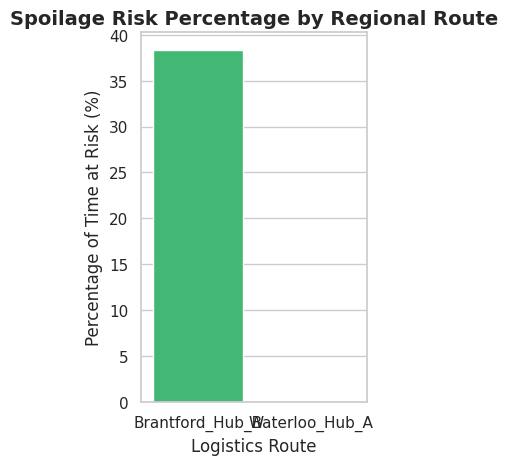

In [19]:
# Defines the first subplot in a 1-row, 2-column grid.
plt.subplot(1, 2, 1)
# Creates a bar plot using Seaborn, showing 'risk_percentage' for each 'route_id'.
# The `palette` helps visually distinguish between routes, often indicating a problem route.
sns.barplot(data=risk_summary, x='route_id', y='risk_percentage', hue='route_id', palette=['#2ecc71', '#e74c3c'], legend=False)
# Adds a descriptive title and labels for clarity.
plt.title('Spoilage Risk Percentage by Regional Route', fontsize=14, weight='bold')
plt.ylabel('Percentage of Time at Risk (%)')
plt.xlabel('Logistics Route')

Immediate Hardware Inspection & Repair: The most critical step is to promptly inspect and repair or replace the refrigeration units on trucks identified with temperature violations (like the Brantford route). This will directly address the cause of the rising temperatures.

Proactive Maintenance Schedule: Implement a more rigorous maintenance schedule for all refrigeration units. Regular checks can catch potential failures before they lead to cargo spoilage.

Enhanced Monitoring & Alert System: Ensure our monitoring system is robust and provides real-time alerts to dispatch or maintenance teams as soon as temperatures approach the safety threshold. This allows for quicker intervention.

Driver Training & Awareness: Train drivers on what to do if they see temperature warnings and how to report issues immediately. Early detection by drivers can be crucial.

Contingency Planning: Have a plan in place for situations where a refrigeration unit fails mid-route, such as having backup vehicles or alternative cold storage options at strategic points.

The goal is to ensure the integrity of our cold chain, prevent product loss, and maintain customer trust. The data clearly shows where our efforts should be concentrated first.

### Visual 2: Temperature vs. Time Scatter Plot (Focusing on the Failing Route)

This detailed line plot helps pinpoint *when* and *how* the temperature violation occurred for a specific route, invaluable for root cause analysis.

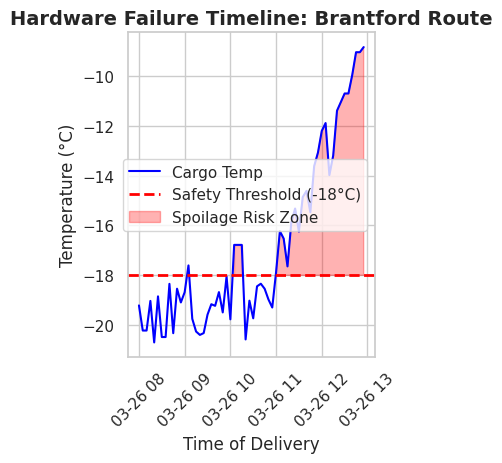

In [17]:
# Defines the second subplot.
plt.subplot(1, 2, 2)
# Filters the `clean_data` to only include records for the 'Brantford_Hub_B' route, which had the simulated failure.
brantford_clean = clean_data[clean_data['route_id'] == 'Brantford_Hub_B']

# Creates a line plot showing 'cargo_temp_celsius' over 'timestamp' for the Brantford route.
sns.lineplot(data=brantford_clean, x='timestamp', y='cargo_temp_celsius', color='blue', label='Cargo Temp')
# Draws a horizontal line at the `SAFETY_THRESHOLD`, making it easy to see when temperatures exceed the safe limit.
plt.axhline(SAFETY_THRESHOLD, color='red', linestyle='--', linewidth=2, label='Safety Threshold (-18°C)')

# Fills the area between the cargo temperature line and the safety threshold line when the temperature is above the threshold.
# This visually highlights the periods of spoilage risk, making anomalies immediately obvious.
plt.fill_between(brantford_clean['timestamp'],
                 brantford_clean['cargo_temp_celsius'],
                 SAFETY_THRESHOLD,
                 where=(brantford_clean['cargo_temp_celsius'] > SAFETY_THRESHOLD),
                 color='red', alpha=0.3, label='Spoilage Risk Zone')

# Adds titles, labels, rotates x-axis labels for readability, and displays a legend.
plt.title('Hardware Failure Timeline: Brantford Route', fontsize=14, weight='bold')
plt.ylabel('Temperature (°C)')
plt.xlabel('Time of Delivery')
plt.xticks(rotation=45)
plt.legend()

# Adjusts plot parameters for a tight layout, preventing labels and titles from overlapping.
plt.tight_layout()
# Displays all generated plots.
plt.show()

My suggestion to stakeholders: Gordon Food Service should map out more morning routes with minimal traffic and fine-tune the welfare of the drivers for having to take that route.